<a href="https://colab.research.google.com/github/AHMADAMJAD0/Pytorch/blob/main/pytorch_training__pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

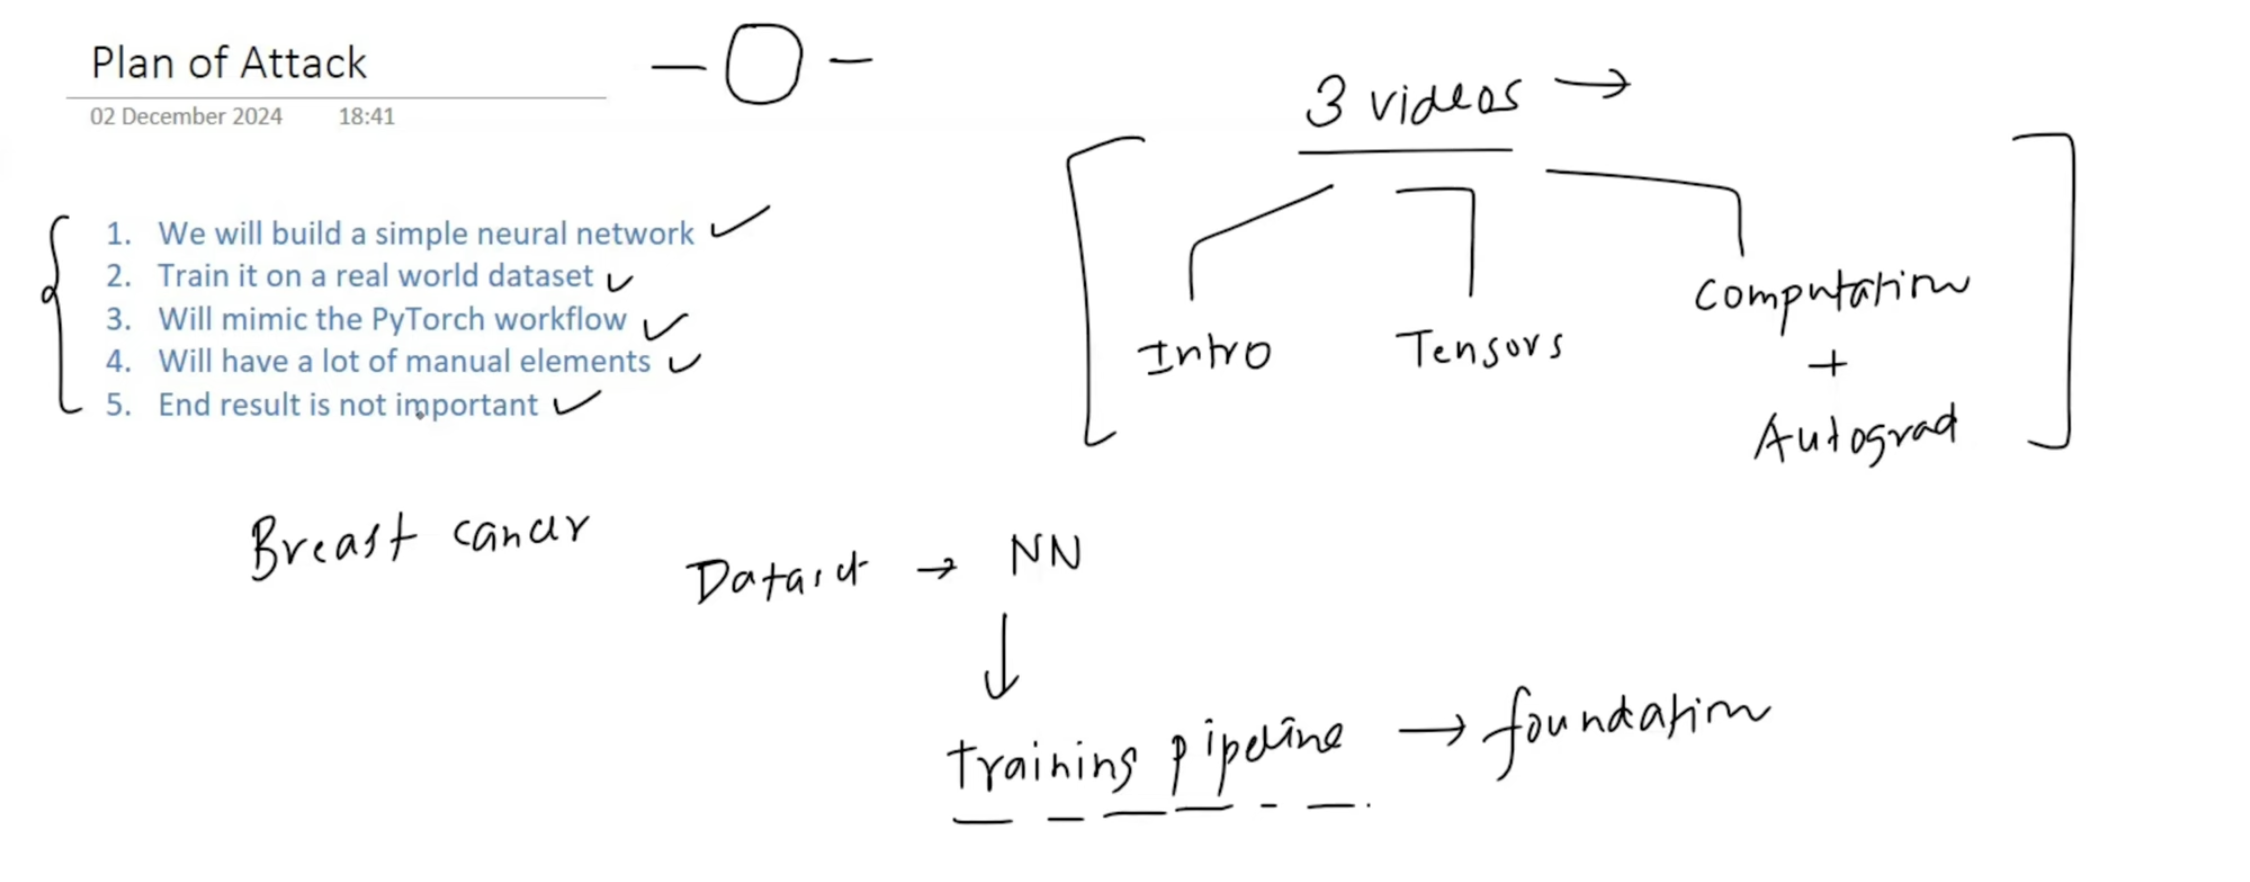







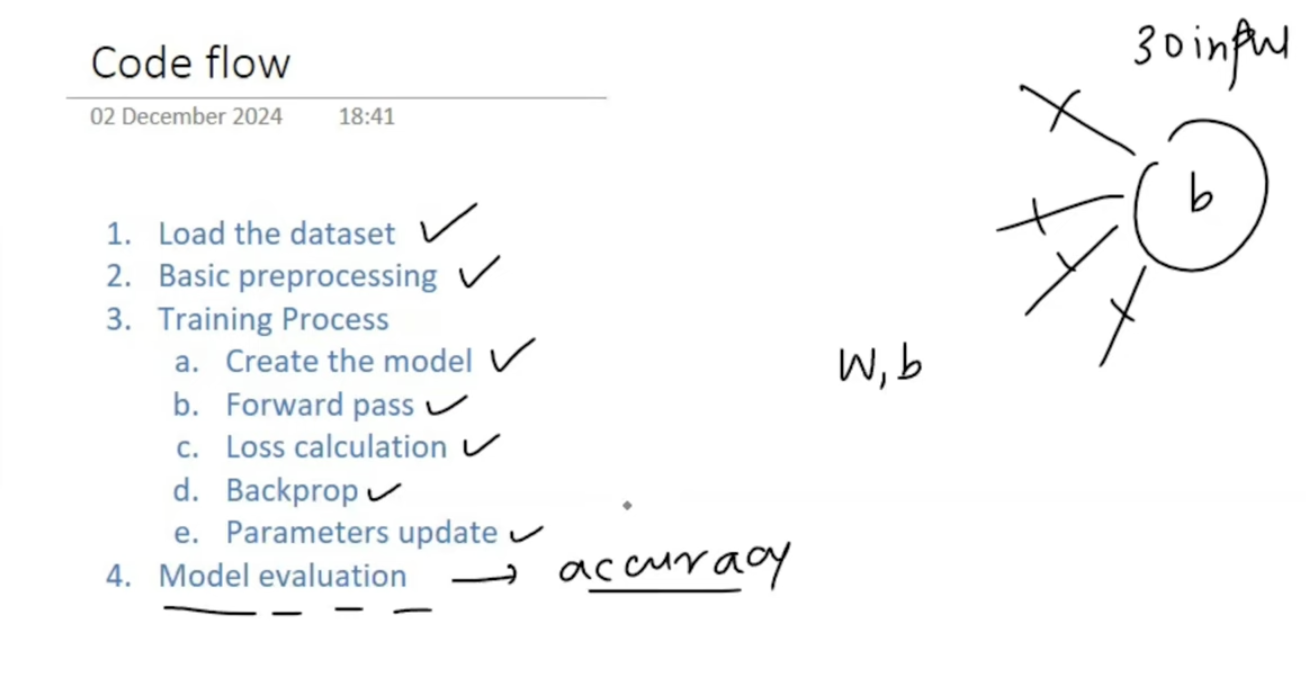

In [ ]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.shape

(569, 33)

In [ ]:
df.drop(columns=['id' , 'Unnamed: 32'] ,inplace=True) # -> inplace=True -> Original DataFrame ko direct change kar do, naya DataFrame return na karo.

In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
df.shape

(569, 31)

**train_test_split**


In [ ]:
x_train , x_test , y_train , y_test = train_test_split(df.iloc[:,1:] , df.iloc[:,0], test_size=0.2)

**Scaling**

scaling ka mean hai values ko scale kerna jo columns ki values hn un ko same number man convert kerna

hum aysa is lia kerty hn kh jab hum NN man kam kerty hn tu scaling hona zrori hota hai is lia hum ya steps ker rhy hn


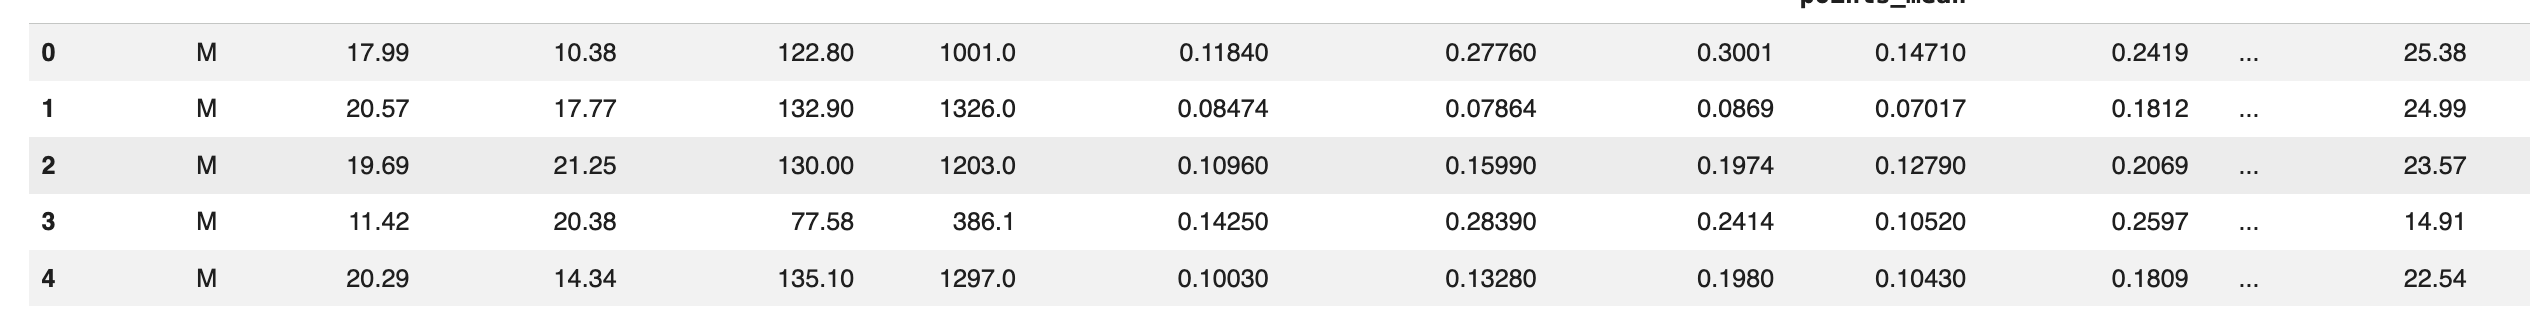









In [ ]:
# why we are useing this function
# the answer is we have a dataset which is not same leanth and it would not done the training without equal of data so that
# you can see the uper output values showing not equal
#that is why we use this function
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train

array([[ 0.36929164, -1.36206526,  0.30025253, ..., -0.46875341,
        -0.64859754, -0.87489183],
       [ 1.67501777,  3.03160146,  1.62888462, ...,  0.78445119,
        -0.27452068, -0.43203751],
       [-1.13199254, -0.38797612, -1.12687783, ..., -1.18400533,
        -0.01796355, -0.29896034],
       ...,
       [-1.49302281, -1.0905978 , -1.5073    , ..., -1.52276802,
         0.18562696, -0.30172128],
       [-0.80405672, -1.40084633, -0.81255894, ..., -0.37994852,
        -0.24141654, -0.18134442],
       [-0.45205221,  0.16180253, -0.4535875 , ..., -0.55460848,
        -0.32086649, -0.32380878]])

In [ ]:
y_train

,diagnosis
371,B
219,M
217,B
235,B
465,B
...,...
562,M
342,B
307,B
271,B


**Label Encoder**

ya hum is lia ker rhy hn kah hamara model alphabets ko nae smjh skta is lia hum in ko number man convert kerny lgy hn ta kh hum model per kam ker skyn **diagnosis** column ki value alphabets hn


In [ ]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [ ]:
y_train

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,

**numpy array to pytorch**

In [ ]:
x_train_tensor = torch.from_numpy(x_train)
x_test_tensor = torch.from_numpy(x_test)
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)


In [ ]:
x_train_tensor = x_train_tensor.float()
x_test_tensor = x_test_tensor.float()

y_train_tensor = y_train_tensor.float()
y_test_tensor = y_test_tensor.float()

In [ ]:
x_train_tensor.shape

torch.Size([455, 30])

In [ ]:
x_train_tensor.dtype

torch.float64

In [ ]:
x_train_tensor

tensor([[ 0.3693, -1.3621,  0.3003,  ..., -0.4688, -0.6486, -0.8749],
        [ 1.6750,  3.0316,  1.6289,  ...,  0.7845, -0.2745, -0.4320],
        [-1.1320, -0.3880, -1.1269,  ..., -1.1840, -0.0180, -0.2990],
        ...,
        [-1.4930, -1.0906, -1.5073,  ..., -1.5228,  0.1856, -0.3017],
        [-0.8041, -1.4008, -0.8126,  ..., -0.3799, -0.2414, -0.1813],
        [-0.4521,  0.1618, -0.4536,  ..., -0.5546, -0.3209, -0.3238]],
       dtype=torch.float64)

In [ ]:
y_train_tensor.shape

torch.Size([455])

# **Defining the model**

In [ ]:

import torch
import torch.nn as nn
class mysimplenn(nn.Module):

  # use built_in activation function
    def __init__(self, num_features):
        super().__init__()
      # x.shape[1] means number of features
        self.linear = nn.Linear(num_features , 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)
        return out


        # we will not use this lose function becous this create by its self we will use built_in loss function

    # def loss_function(self, y_pred, y):
    #     # avoid log(0)
    #     # Hum is liye use karte hain taake prediction exactly 0 ya 1 na ban jaye.
    #     epsilon = 1e-7

    #     # torch.clamp() keeps y_pred between 0.0000001 and 0.9999999
    #     # so the loss calculation does not break.
    #     y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    #     # make y shape same as y_pred
    #     y = y.view(-1, 1).type_as(y_pred)

    #     # binary cross entropy loss
    #     loss = -(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred)).mean()

    #     return loss








In [ ]:
# define loss function
loss_function = nn.BCELoss() #BCELoss -> binary coss entropy loss function

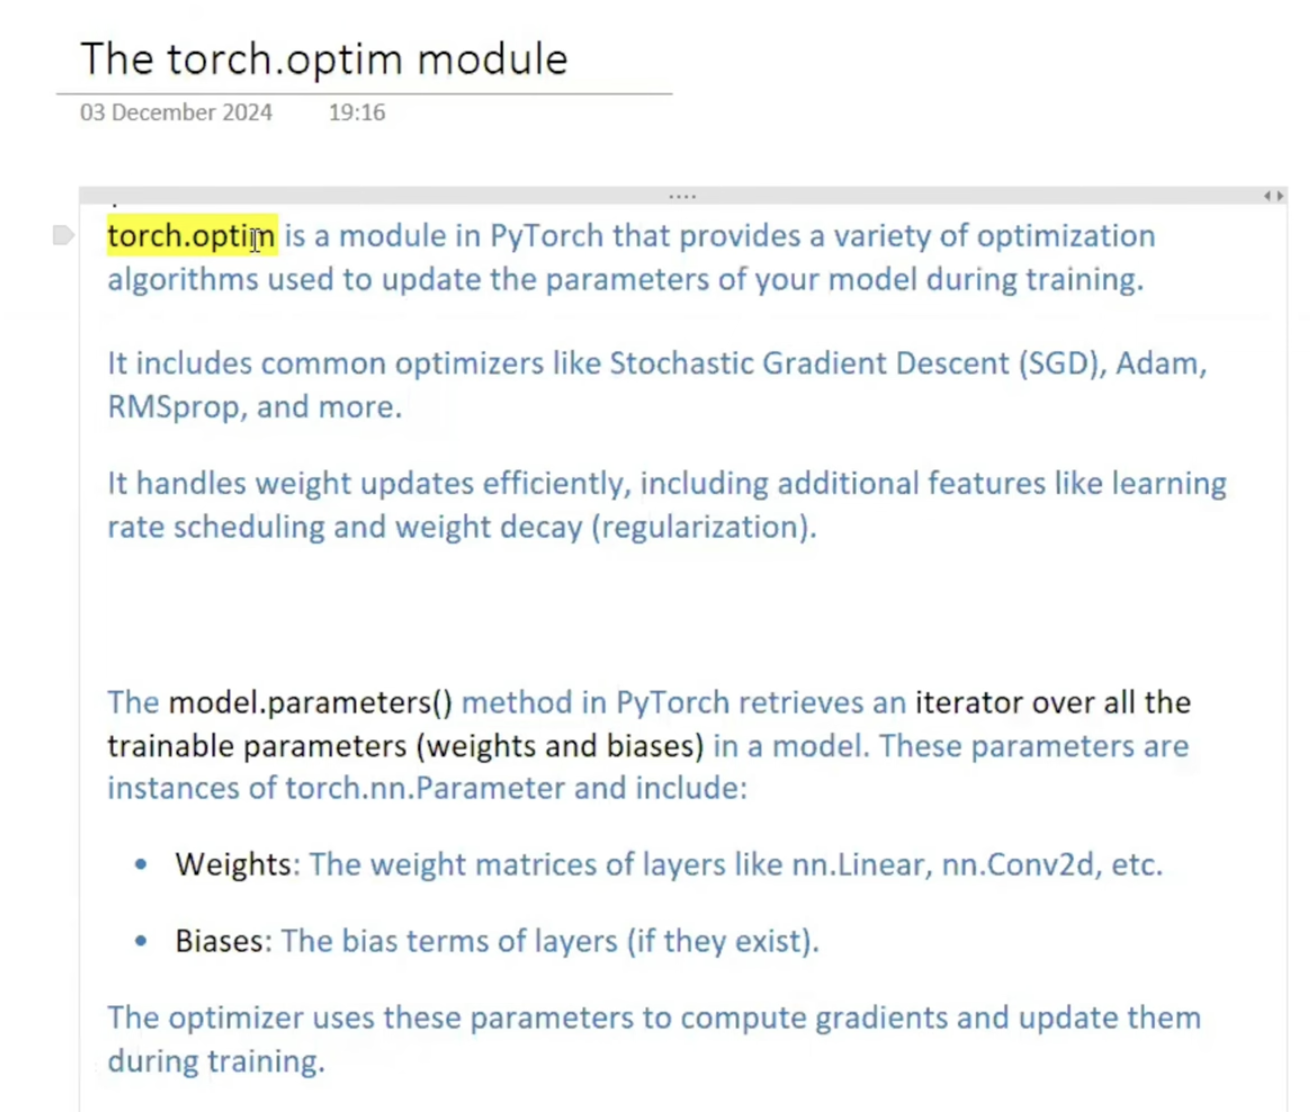

# **Importent parameters**

In [ ]:
learning_rate = 0.1
epochs = 25

# **Training pipeline**

In [ ]:
# create model
model = mysimplenn(x_train_tensor.shape[1])

optimizer = torch.optim.SGD(model.parameters(), lr =learning_rate)

# define loop  -> hum ya jo 4 steps han in ko loop man kerty hain
# kitny dafa hum loop chlay gay ? -> jitni hum nay epoch set kia hai remmeber this words
for epoch in range(epochs):
# 1 .forword pass
   y_pred = model(x_train_tensor)
   #print(y_pred)

# 2 .loss calculate
   loss = loss_function(y_pred , y_train_tensor.view(-1,1)) # .view keyword use for the reshape


# # zeros gradiants
#    model.linear.weight.grad.zero_()
#    model.linear.bias.grad.zero_()

   optimizer.zero_grad() # now automatically convert zero gradients


# 3 .backword pass

   loss.backward()

# its a difficult beacouse we are making the code by self logic so that is why its tough its a simple way is use optim function

# # 4 .parameter update
   optimizer.step()
# # its a imp step
#    with torch.no_grad():
#      model.linear.weight -= learning_rate * model.linear.weight.grad
#      model.linear.bias -= learning_rate * model.linear.bias.grad




   # print each epoch utems
   print(f'epoch :"{epoch + 1} , Loss : {loss.item()}')


epoch :"1 , Loss : 0.9458112716674805
epoch :"2 , Loss : 0.6697742938995361
epoch :"3 , Loss : 0.5309133529663086
epoch :"4 , Loss : 0.45205432176589966
epoch :"5 , Loss : 0.40065479278564453
epoch :"6 , Loss : 0.36393848061561584
epoch :"7 , Loss : 0.3360506594181061
epoch :"8 , Loss : 0.3139350712299347
epoch :"9 , Loss : 0.2958327829837799
epoch :"10 , Loss : 0.2806541323661804
epoch :"11 , Loss : 0.26768407225608826
epoch :"12 , Loss : 0.2564316689968109
epoch :"13 , Loss : 0.2465469092130661
epoch :"14 , Loss : 0.23777280747890472
epoch :"15 , Loss : 0.22991573810577393
epoch :"16 , Loss : 0.22282661497592926
epoch :"17 , Loss : 0.21638859808444977
epoch :"18 , Loss : 0.21050851047039032
epoch :"19 , Loss : 0.20511114597320557
epoch :"20 , Loss : 0.20013496279716492
epoch :"21 , Loss : 0.19552907347679138
epoch :"22 , Loss : 0.19125086069107056
epoch :"23 , Loss : 0.18726444244384766
epoch :"24 , Loss : 0.18353931605815887
epoch :"25 , Loss : 0.18004928529262543


In [ ]:
model.linear.weight

Parameter containing:
tensor([[ 0.0864,  0.2123,  0.1210,  0.3330,  0.1316,  0.2925,  0.1693,  0.3183,
         -0.0363, -0.1223,  0.2983,  0.0628,  0.1719,  0.3552, -0.1380, -0.0363,
          0.0216, -0.0117,  0.0897, -0.1878,  0.4012,  0.2041,  0.1852,  0.1956,
          0.1538,  0.2698,  0.1914,  0.1578,  0.1855,  0.1187]],
       requires_grad=True)

In [ ]:
model.linear.bias

Parameter containing:
tensor([-0.0734], requires_grad=True)

# **model evaluation**

In [ ]:
# model evaluation
with torch.no_grad():
  y_pred = model.forward(x_test_tensor)
  y_pred = (y_pred > 0.5).float() # -> y_pred man jo value han is line k run kerny sy phly wp smjh nae a rhi thi tu hum nay ya step kia or is man ya ho raha hai
  # y_pred m jo value hai aghr wo 0.5 sy bri hai tu is ko 1 keh do or choti ko 0 keh do or value float ma rkho

  print(y_pred)

tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
      

In [ ]:
  accuracey = (y_pred == y_test_tensor).float().mean()
  print(f'accuracey : {accuracey}')

accuracey : 0.5086180567741394


1 .data load -> data ko load kia

2 .data cleaning -> to clean the data

3 .model training -> to devide the data acording to the bach -> train_test_spilit

5 .data preprocessing -> data scaling -> to same size of value

6 .data preprocessing -> label -> to label the alphabets becouse model
cant understand alphabet that is why convert into number

7 .imp step -> numpy array to pytorch with -> pytorch.from_numpy

8 .set importent parameters like learning rate , epoch

9 . creat a nn class and inside create the function like -> forword -> loss function -> backword -> update -> evaluation
